In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
import xobjects as xo
import xpart as xp
import xcoll as xc
import json

In [2]:
def zero_sextupoles(line: xt.Line) -> None:
    tt_vars = line.vars.get_table()
    for kk in tt_vars.rows['kls.*'].name:
        line[kk] = 0.0

    for kk in tt_vars.rows['kl.*'].name:
        line[kk] = 0.0
    for kk in tt_vars.rows['ks.*'].name:
        line[kk] = 0.0
    tw = line.twiss()
    print(tw.qx, tw.qy, tw.dqx, tw.dqy)

In [14]:
def df_to_delta(df_hz: np.ndarray | float) -> np.ndarray | float:
    sps_gtr = 17.95
    sps_g0 = 27.643
    f0 = 200e6
    eta = 1 / sps_gtr**2 - 1 / sps_g0**2
    return -np.asarray(df_hz) / (f0 * eta)

In [3]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )
tw_ref = line.twiss()
zero_sextupoles(line)
tw = line.twiss()
# print(tw.qx, tw.qy, tw.dqx, tw.dqy)


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 6.3976e-06              
Optimize - end penalty:  6.39758e-06                            
20.130029320948722 20.180030229082664 -22.664668975699243 -22.75062495235352


# Checking sweep trajectory

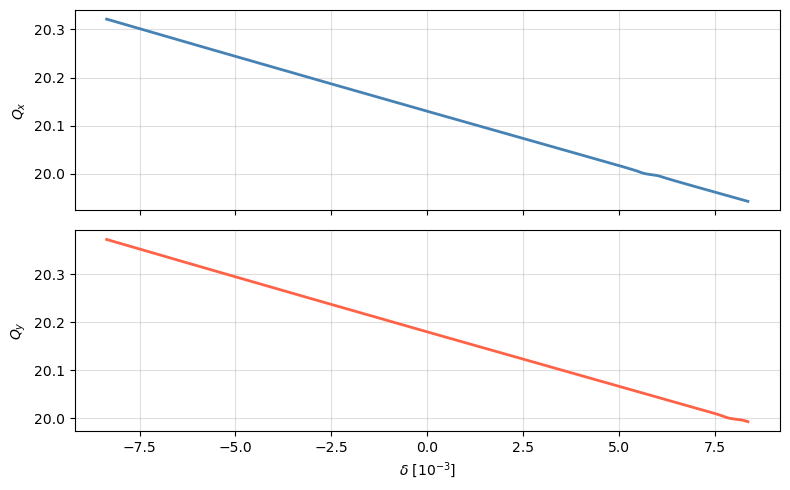

In [11]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys

repo = Path("/Users/lisepauwels/phd/code/sps-momentum-acceptance")
sys.path.insert(0, str(repo / "tune_scan_workflow"))

from tune_diagram import TuneDiagram, TuneMap

tune_map_path = repo / "tests" / "sextupoles_off" / "tune_map_sextupoles_off_shared.npz"
tm = TuneMap.load(str(tune_map_path))

fig, ax = tm.plot_map()
# plt.show()

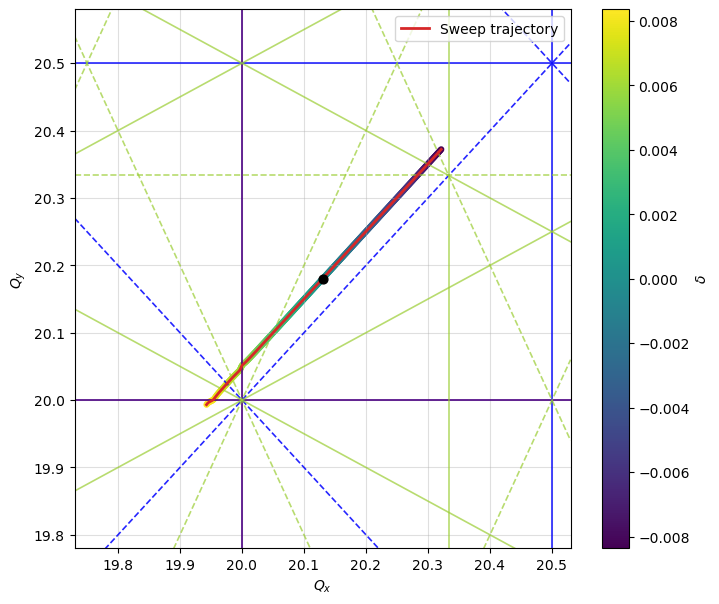

In [13]:
tune_map_path = repo / "tests" / "sextupoles_off" / "tune_map_sextupoles_off_shared.npz"
tm = TuneMap.load(str(tune_map_path))

delta = np.linspace(tm.delta_min, tm.delta_max, 400)
qx, qy = tm(delta)

qx0, qy0 = tm(0.0, extrapolate=True)
td = TuneDiagram(qx0=qx0, qy0=qy0, half_range=0.4, max_order=3, skew=True)
fig, ax = td.plot(figsize=(8, 7), show_working_point=True)

ax.plot(qx, qy, color="tab:red", lw=2, label="Sweep trajectory")
sc = ax.scatter(qx, qy, c=delta, cmap="viridis", s=12)

td.finalize(ax, extra_handles=None)
ax.legend(loc="best")
fig.colorbar(sc, ax=ax, label=r"$\delta$")

# Without sextupoles

In [15]:
dico = {'Without sextupoles': {}, 'With sextupoles': {}}

## DPpos

In [16]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )
tw_ref = line.twiss()
zero_sextupoles(line)
tw = line.twiss()
# print(tw.qx, tw.qy, tw.dqx, tw.dqy)


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 6.3976e-06              
Optimize - end penalty:  6.39758e-06                            
20.130029320948722 20.180030229082664 -22.664668975699243 -22.75062495235352


In [17]:
num_particles  = 500
num_turns = 6000

sweep = 3000
plane = 'DPpos'

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [18]:
#Params
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

#Generating the particles
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                        nemitt_y=nemitt_y,
                                        sigma_z=sigma_z, num_particles=num_particles, line=line)

#Tracking
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
rf_sweep = xc.RFSweep(line)
rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
rf_sweep.info()

line.scattering.enable()
line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
line.scattering.disable()

turns, counts = np.unique(part.at_turn, return_counts=True)

turns = np.concatenate(([0], turns))
counts = np.concatenate(([0], counts))
deltas = df_to_delta(turns * sweep / num_turns)
dico['Without sextupoles'][plane] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

*** Maximum RMS bunch length 0.23610110400434295m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.22399999989004865
--> Emittance: 0.279717871043194
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.


...

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 199999999.5Hz, adding -0.5Hz per turn.
This sweep will move the center of the bucket with Δδ = 1.394e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 4278.19 turns.
No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

No xcoll elements found in line.


## DPneg

In [19]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )
tw_ref = line.twiss()
zero_sextupoles(line)
tw = line.twiss()
# print(tw.qx, tw.qy, tw.dqx, tw.dqy)


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 6.3976e-06              
Optimize - end penalty:  6.39758e-06                            
20.130029320948722 20.180030229082664 -22.664668975699243 -22.75062495235352


In [20]:
num_particles  = 500
num_turns = 6000

sweep = 3000
plane = 'DPneg'

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [21]:
#Params
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

#Generating the particles
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                        nemitt_y=nemitt_y,
                                        sigma_z=sigma_z, num_particles=num_particles, line=line)

#Tracking
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
rf_sweep = xc.RFSweep(line)
rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
rf_sweep.info()

line.scattering.enable()
line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
line.scattering.disable()

turns, counts = np.unique(part.at_turn, return_counts=True)

turns = np.concatenate(([0], turns))
counts = np.concatenate(([0], counts))
deltas = df_to_delta(turns * sweep / num_turns)
dico['Without sextupoles'][plane] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

*** Maximum RMS bunch length 0.23610110400434295m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.22399999989004865
--> Emittance: 0.279717871043194
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.


...

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 200000000.5Hz, adding 0.5Hz per turn.
This sweep will move the center of the bucket with Δδ = -1.394e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 4278.19 turns.
No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

No xcoll elements found in line.


## Intensity plot

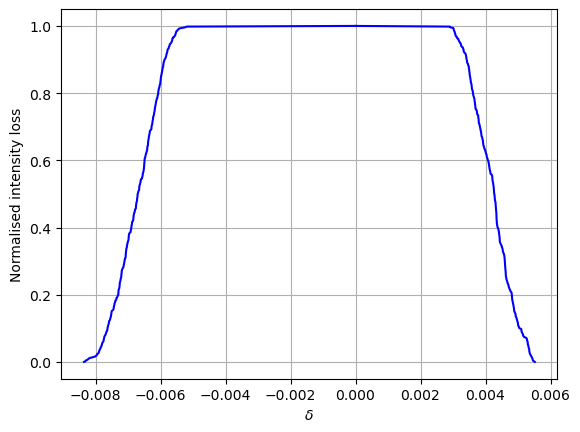

In [22]:
fig, ax = plt.subplots()
ax.plot(dico['Without sextupoles']['DPneg']['deltas'], dico['Without sextupoles']['DPneg']['survival'], color='blue')
ax.plot(dico['Without sextupoles']['DPpos']['deltas'], dico['Without sextupoles']['DPpos']['survival'], color='blue')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel('Normalised intensity loss')
ax.grid()

# Negative sweep with positive natural chroma
Should give worse momentum acceptance if sextupoles play a big role

In [23]:
tw.dqx, tw.dqy

(np.float64(-22.664668975699243), np.float64(-22.75062495235352))

In [24]:
xi_x = abs(tw.dqx.copy()) / abs(tw.qx.copy())
xi_y = abs(tw.dqy.copy()) / abs(tw.qy.copy())

print(xi_x, xi_y)

1.1259133612941536 1.1273830957679247


In [25]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )

tw = line.twiss()
# print(tw.qx, tw.qy, tw.dqx, tw.dqy)


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 32.06                             
Matching: model call n. 15 penalty = 1.3826e-05              
Optimize - end penalty:  1.38257e-05                            


In [26]:
num_particles  = 500
num_turns = 6000

sweep = 3000
plane = 'DPneg'

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [27]:
#Params
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

#Generating the particles
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                        nemitt_y=nemitt_y,
                                        sigma_z=sigma_z, num_particles=num_particles, line=line)

#Tracking
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
rf_sweep = xc.RFSweep(line)
rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
rf_sweep.info()

line.scattering.enable()
line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
line.scattering.disable()

turns, counts = np.unique(part.at_turn, return_counts=True)

turns = np.concatenate(([0], turns))
counts = np.concatenate(([0], counts))
deltas = df_to_delta(turns * sweep / num_turns)
dico['With sextupoles'][plane] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

*** Maximum RMS bunch length 0.23610110400434298m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.2239999998900486
--> Emittance: 0.27971482876805454
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Slicing line:   0%|          | 0/32538 [00:00<?, ?it/s]

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 200000000.5Hz, adding 0.5Hz per turn.
This sweep will move the center of the bucket with Δδ = -1.394e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 4278.23 turns.
No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

No xcoll elements found in line.


## DPpos

In [28]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )

tw = line.twiss()
# print(tw.qx, tw.qy, tw.dqx, tw.dqy)


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 32.06                             
Matching: model call n. 15 penalty = 1.3826e-05              
Optimize - end penalty:  1.38257e-05                            


In [ ]:
num_particles  = 500
num_turns = 6000

sweep = 3000
plane = 'DPpos'

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [30]:
#Params
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

#Generating the particles
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                        nemitt_y=nemitt_y,
                                        sigma_z=sigma_z, num_particles=num_particles, line=line)

#Tracking
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
rf_sweep = xc.RFSweep(line)
rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
rf_sweep.info()

line.scattering.enable()
line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
line.scattering.disable()

turns, counts = np.unique(part.at_turn, return_counts=True)

turns = np.concatenate(([0], turns))
counts = np.concatenate(([0], counts))
deltas = df_to_delta(turns * sweep / num_turns)
dico['With sextupoles'][plane] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

*** Maximum RMS bunch length 0.23610110400434298m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.2239999998900486
--> Emittance: 0.27971482876805454
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.


...

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 199999999.5Hz, adding -0.5Hz per turn.
This sweep will move the center of the bucket with Δδ = 1.394e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 4278.23 turns.
No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

No xcoll elements found in line.


## Intensity plot

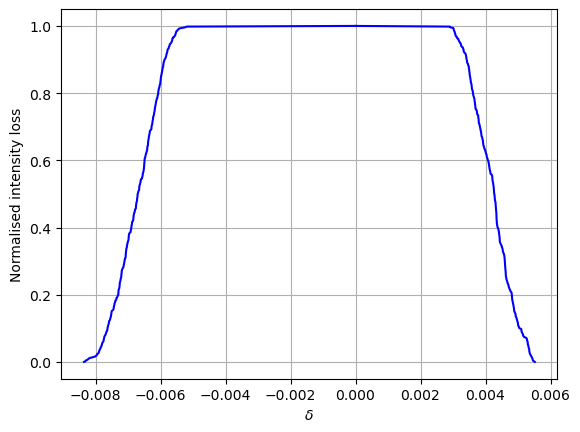

In [31]:
fig, ax = plt.subplots()
ax.plot(dico['Without sextupoles']['DPneg']['deltas'], dico['Without sextupoles']['DPneg']['survival'], color='blue')
ax.plot(dico['Without sextupoles']['DPpos']['deltas'], dico['Without sextupoles']['DPpos']['survival'], color='blue')
ax.set_xlabel(r'$\delta$')
ax.set_ylabel('Normalised intensity loss')
ax.grid()

# Comparing with/without sextupoles

50% point without sextupoles: 0.004266088656107829
50% point with sextupoles: -0.004076670419989428


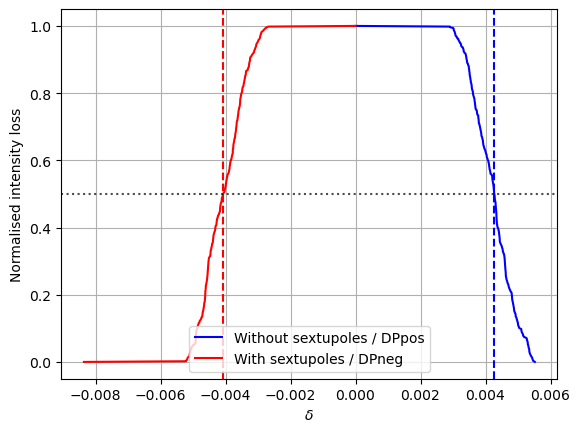

In [32]:
fig, ax = plt.subplots()

x1 = np.asarray(dico['Without sextupoles']['DPpos']['deltas'])
y1 = np.asarray(dico['Without sextupoles']['DPpos']['survival'])
x2 = np.asarray(dico['With sextupoles']['DPneg']['deltas'])
y2 = np.asarray(dico['With sextupoles']['DPneg']['survival'])

ax.plot(x1, y1, color='blue', label='Without sextupoles / DPpos')
ax.plot(x2, y2, color='red', label='With sextupoles / DPneg')

delta_50_1 = np.interp(0.5, y1[::-1], x1[::-1])
delta_50_2 = np.interp(0.5, y2[::-1], x2[::-1])

ax.axvline(delta_50_1, color='blue', ls='--')
ax.axvline(delta_50_2, color='red', ls='--')
ax.axhline(0.5, color='black', ls=':', alpha=0.7)

ax.set_xlabel(r'$\delta$')
ax.set_ylabel('Normalised intensity loss')
ax.grid()
ax.legend()

print("50% point without sextupoles:", delta_50_1)
print("50% point with sextupoles:", delta_50_2)

needs more statistics to be conclusive I would say

# More stats

In [50]:
dico2 = {'Without sextupoles': {}, 'With sextupoles': {}}

## DPpos without sextupoles

In [51]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )
tw_ref = line.twiss()
zero_sextupoles(line)
tw = line.twiss()
# print(tw.qx, tw.qy, tw.dqx, tw.dqy)


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 14.2                              
Matching: model call n. 15 penalty = 6.3976e-06              
Optimize - end penalty:  6.39758e-06                            
20.130029320948722 20.180030229082664 -22.664668975699243 -22.75062495235352


In [52]:
num_particles  = 10000
num_turns = 6000

sweep = 6000
plane = 'DPpos'

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [53]:
#Params
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

#Generating the particles
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                        nemitt_y=nemitt_y,
                                        sigma_z=sigma_z, num_particles=num_particles, line=line)

#Tracking
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
rf_sweep = xc.RFSweep(line)
rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
rf_sweep.info()

line.scattering.enable()
line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
line.scattering.disable()

turns, counts = np.unique(part.at_turn, return_counts=True)

turns = np.concatenate(([0], turns))
counts = np.concatenate(([0], counts))
deltas = df_to_delta(turns * sweep / num_turns)
dico2['Without sextupoles'][plane] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

*** Maximum RMS bunch length 0.23610110400434295m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.22399999989004865
--> Emittance: 0.279717871043194
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...
Done compiling ContextCpu kernels.

ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Slicing line:   0%|          | 0/32538 [00:00<?, ?it/s]

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 199999999.0Hz, adding -1.0Hz per turn.
This sweep will move the center of the bucket with Δδ = 2.788e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 2139.09 turns.
No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

KeyboardInterrupt: 

## DPneg with sextupoles

In [ ]:
xi_x = abs(tw.dqx.copy()) / abs(tw.qx.copy())
xi_y = abs(tw.dqy.copy()) / abs(tw.qy.copy())

print(xi_x, xi_y)

1.1259133612941536 1.1273830957679247


In [ ]:
line = xt.load(Path('/Users/lisepauwels/phd/code/sps-xsuite-model/sps_with_aperture_inj_q20_beam_sagitta4.json'))
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

qx = 20.13
qy = 20.18

line.match(
        method="6d",
        vary=[
            xt.VaryList(["kqf0", "kqd0"], step=1e-8, tag="quad"),
            xt.VaryList(["qph_setvalue", "qpv_setvalue"], step=1e-4, tag="sext"),
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag="tune"),
            xt.TargetSet(dqx=xi_x * qx, dqy=xi_y * qy, tol=1e-2, tag="chrom"),
        ],
    )

tw = line.twiss()
# print(tw.qx, tw.qy, tw.dqx, tw.dqy)


Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

/Users/lisepauwels/Xsuite/xtrack/xtrack/beam_elements/elements.py:2809: FutureWarning: The `Solenoid` element is deprecated. Use `VariableSolenoid` or `UniformSolenoid` instead.
  warn(


Done loading line from dict.           
                                             
Optimize - start penalty: 32.06                             
Matching: model call n. 15 penalty = 1.3826e-05              
Optimize - end penalty:  1.38257e-05                            


In [ ]:
num_particles  = 10000
num_turns = 6000

sweep = 6000
plane = 'DPneg'

nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224

In [ ]:
#Params
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)

#Generating the particles
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                        nemitt_y=nemitt_y,
                                        sigma_z=sigma_z, num_particles=num_particles, line=line)

#Tracking
line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
rf_sweep = xc.RFSweep(line)
rf_sweep.prepare(sweep_per_turn=sweep/num_turns)
rf_sweep.info()

line.scattering.enable()
line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
line.scattering.disable()

turns, counts = np.unique(part.at_turn, return_counts=True)

turns = np.concatenate(([0], turns))
counts = np.concatenate(([0], counts))
deltas = df_to_delta(turns * sweep / num_turns)
dico2['With sextupoles'][plane] = {'deltas' : deltas.copy(), 'survival' : 1 - np.cumsum(counts.copy()) / num_particles}

*** Maximum RMS bunch length 0.23610110400434298m.
... distance to target bunch length: -2.2226e-01
... distance to target bunch length: 5.5784e-03
... distance to target bunch length: 5.2361e-03
... distance to target bunch length: -6.3267e-03
... distance to target bunch length: 1.9948e-03
... distance to target bunch length: -3.8258e-04
... distance to target bunch length: 5.3833e-05
... distance to target bunch length: 1.2594e-06
... distance to target bunch length: -1.0995e-10
... distance to target bunch length: 1.2805e-07
--> Bunch length: 0.2239999998900486
--> Emittance: 0.27971482876805454
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.


...

Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.
Enabled time-dependent variables in the line.
The current frequency is 200000001.0Hz, adding 1.0Hz per turn.
This sweep will move the center of the bucket with Δδ = -2.788e-06 per turn.
The bucket height is 0.002982, so this implies the sweep will shift one bucket every 2139.12 turns.
No xcoll elements found in line.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

No xcoll elements found in line.


## Comparison

50% point without sextupoles: 0.004583642757835738
50% point with sextupoles: -0.004371243632776501


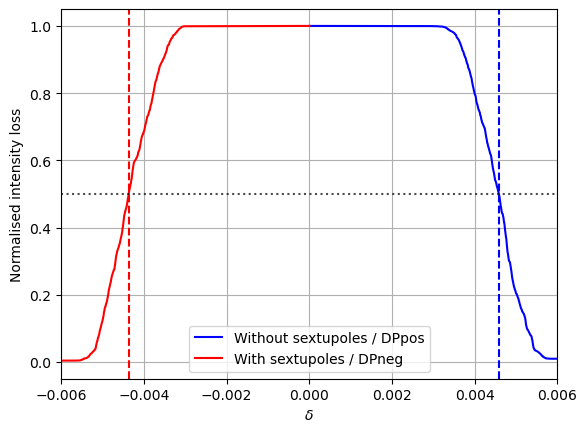

In [ ]:
fig, ax = plt.subplots()

x1 = np.asarray(dico2['Without sextupoles']['DPpos']['deltas'])
y1 = np.asarray(dico2['Without sextupoles']['DPpos']['survival'])
x2 = np.asarray(dico2['With sextupoles']['DPneg']['deltas'])
y2 = np.asarray(dico2['With sextupoles']['DPneg']['survival'])

ax.plot(x1, y1, color='blue', label='Without sextupoles / DPpos')
ax.plot(x2, y2, color='red', label='With sextupoles / DPneg')

delta_50_1 = np.interp(0.5, y1[::-1], x1[::-1])
delta_50_2 = np.interp(0.5, y2[::-1], x2[::-1])

ax.axvline(delta_50_1, color='blue', ls='--')
ax.axvline(delta_50_2, color='red', ls='--')
ax.axhline(0.5, color='black', ls=':', alpha=0.7)

ax.set_xlabel(r'$\delta$')
ax.set_ylabel('Normalised intensity loss')
ax.set_xlim(-0.006, 0.006)
ax.grid()
ax.legend()

print("50% point without sextupoles:", delta_50_1)
print("50% point with sextupoles:", delta_50_2)

# Bandwidth of the integer resonance